In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Starting the plant disease classification process using SegNet...
Dataset already extracted!
Loading data...
Found 32572 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Found 10885 images belonging to 38 classes.

Total training samples: 32572
Total validation samples: 10849
Total test samples: 10885
Steps per epoch: 1018
Number of classes: 38
Creating SegNet model...
Starting training...
Epoch 1/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 207s 191ms/step - accuracy: 0.0916 - loss: 14.2200 - val_accuracy: 0.1015 - val_loss: 14.4824 - learning_rate: 0.0010
Epoch 2/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 177s 174ms/step - accuracy: 0.0992 - loss: 14.5192 - val_accuracy: 0.1015 - val_loss: 14.4824 - learning_rate: 0.0010
Epoch 3/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 176s 172ms/step - accuracy: 0.1018 - loss: 14.4769 - val_accuracy: 0.1015 - val_loss: 14.

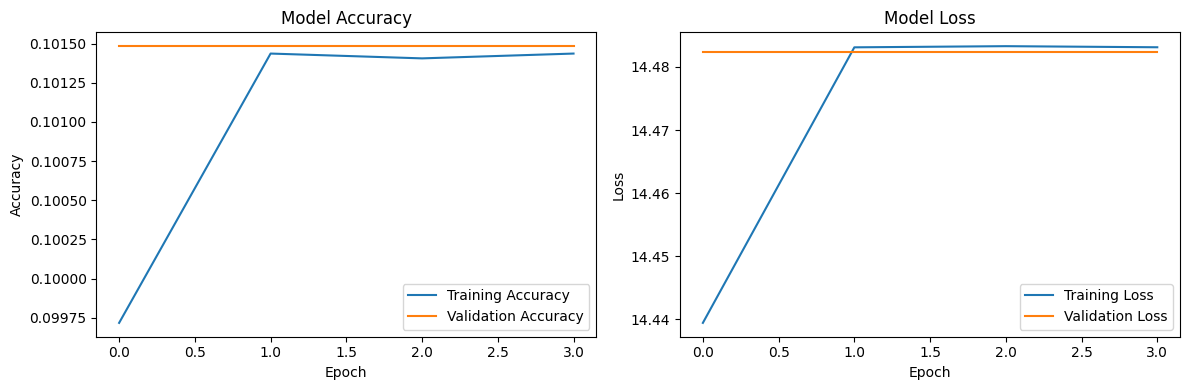

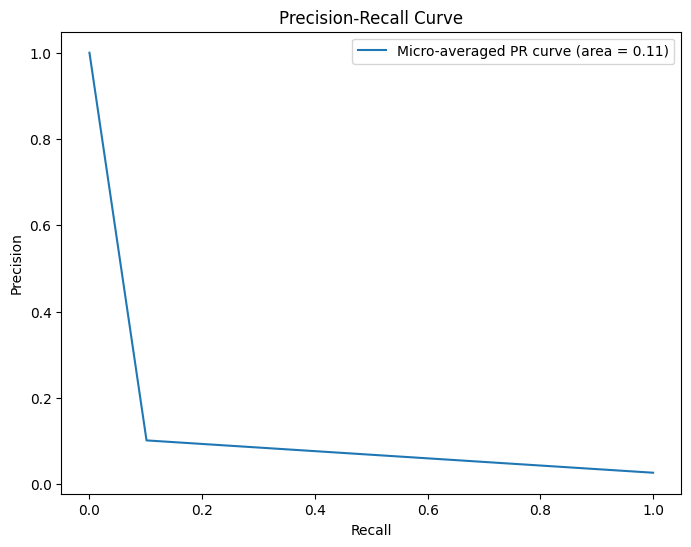


Final Accuracies:
Training Accuracy: 0.1014
Validation Accuracy: 0.1015
Testing Accuracy: 0.1012


In [5]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
from google.colab import drive
import zipfile
from sklearn.metrics import precision_recall_curve, auc

# Enable mixed precision training
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Mount Google Drive
drive.mount('/content/drive')

def extract_dataset():
    zip_path = "/content/drive/MyDrive/Copy of PLANT_VILLAGE_SPLIT.zip"
    extract_path = "/content/plant_village"

    if not os.path.exists(extract_path):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Extraction complete!")
    else:
        print("Dataset already extracted!")
    return extract_path

def create_segnet(input_size=(128, 128, 3), num_classes=38):
    # Encoder
    inputs = Input(input_size)

    # Encoder block 1
    x = Conv2D(64, (3, 3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(64, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Encoder block 2
    x = Conv2D(128, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(128, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Encoder block 3
    x = Conv2D(256, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(256, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Modified decoder for classification instead of segmentation
    x = Conv2D(512, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Classification head
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

def load_data(base_path, img_size=(128, 128)):
    data_generator = ImageDataGenerator(
        rescale=1./255,
        horizontal_flip=True,
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        fill_mode="nearest"
    )

    # Setup data generators
    train_generator = data_generator.flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'train'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=True
    )

    # No augmentation for validation and test
    val_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'val'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'test'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    print(f"\nTotal training samples: {train_generator.n}")
    print(f"Total validation samples: {val_generator.n}")
    print(f"Total test samples: {test_generator.n}")
    print(f"Steps per epoch: {len(train_generator)}")

    return train_generator, val_generator, test_generator

def train_and_evaluate():
    # Extract dataset
    base_path = extract_dataset()

    # Load data
    print("Loading data...")
    train_generator, val_generator, test_generator = load_data(base_path)
    num_classes = len(train_generator.class_indices)
    print(f"Number of classes: {num_classes}")

    # Create and compile model
    print("Creating SegNet model...")
    model = create_segnet(input_size=(128, 128, 3), num_classes=num_classes)

    # Fixed learning rate configuration
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Add callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2
        )
    ]

    # Train model
    print("Starting training...")
    history = model.fit(
        train_generator,
        epochs=10,
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate on test set
    print("Evaluating on test set...")
    test_loss, test_accuracy = model.evaluate(test_generator)
    print(f"Test accuracy: {test_accuracy:.4f}")

    # Get predictions for PR curve
    y_pred = model.predict(test_generator)
    y_test = test_generator.labels
    y_test = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

    # Plot training history
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Plot PR curve
    plt.figure(figsize=(8, 6))
    precision = dict()
    recall = dict()

    for i in range(num_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_pred[:, i])

    precision["micro"], recall["micro"], _ = precision_recall_curve(y_test.ravel(), y_pred.ravel())

    plt.plot(recall["micro"], precision["micro"], label=f'Micro-averaged PR curve (area = {auc(recall["micro"], precision["micro"]):.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

    return (history.history['accuracy'][-1],
            history.history['val_accuracy'][-1],
            test_accuracy)

if __name__ == "__main__":
    print("Starting the plant disease classification process using SegNet...")
    train_acc, val_acc, test_acc = train_and_evaluate()
    print(f"\nFinal Accuracies:")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")